# 6. Graph Data Preparation for GCN and GAT

This notebook prepares the Elliptic Bitcoin transaction dataset for graph neural network modeling. The graph-based models will use transactions as nodes and transaction flows as edges. The objective of this notebook is to align node features, labels, graph edges, and train-validation-test masks so that the data can be used later for GCN and GAT models.

Unlike the tabular baseline models, the graph-based setup keeps the full transaction graph, including unlabeled nodes, because unlabeled nodes may still provide useful neighborhood information during message passing. However, only labeled nodes are used for supervised training, validation, and testing.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 1000)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## 6.1 Load Raw Elliptic Dataset Files

The raw Elliptic files are loaded again so that the full graph can be prepared. The graph neural network setup requires all transaction nodes, all transaction edges, node features, and labels.

In [2]:
# Resolve the project root so the notebook works across different systems
PROJECT_DIR = Path.cwd().resolve()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / "data" / "raw" / "elliptic_bitcoin_dataset"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
GRAPH_DIR = PROCESSED_DIR / "graph_data"
FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"

GRAPH_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

classes_path = DATA_DIR / "elliptic_txs_classes.csv"
edges_path = DATA_DIR / "elliptic_txs_edgelist.csv"
features_path = DATA_DIR / "elliptic_txs_features.csv"

classes_df = pd.read_csv(classes_path)
edges_df = pd.read_csv(edges_path)
features_df = pd.read_csv(features_path, header=None)

print("Classes shape:", classes_df.shape)
print("Edges shape:", edges_df.shape)
print("Features shape:", features_df.shape)

display(classes_df.head())
display(edges_df.head())
display(features_df.head())

Classes shape: (203769, 2)
Edges shape: (234355, 2)
Features shape: (203769, 167)


,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.413965,-0.488307,-0.232553,-0.467516,0.048767,0.052956,-0.039151,-0.172895,-0.163126,-0.160933,0.923473,0.923011,-0.039146,-0.172884,-0.163114,-0.160926,0.923516,0.923110,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264425,-0.250574,-0.263753,-0.169119,-0.167165,-0.059013,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293692,-0.760700,-0.692777,-0.719789,-1.084907,-1.084845,-0.170113,-0.202332,-0.116817,-0.192405,-0.014659,-0.018849,-1.457921,-1.494024,-0.083459,-1.485939,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.121330,-0.110933,-0.075909,-0.111641,-1.159649,-1.160129,-1.373723,-1.353918,-0.295982,-1.403215,-0.975738,-0.975237,-0.168742,-0.263290,-0.186389,-0.250875,-1.015963,-1.016230,-0.968903,0.146997,1.366287,-0.464773,-1.116918,-1.116948,-0.216814,0.634272,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,-0.168576,-0.049707,-0.165054,-0.028741,-0.035391,-0.042955,-0.013282,

## 6.2 Rename Feature Columns and Clean Labels

The feature file does not contain column names. The first column is the transaction identifier and the second column is the time step. The remaining columns are anonymized numerical features.

In [3]:
features_df = features_df.rename(columns={0: "txId", 1: "time_step"})

# Standardize class labels as strings
classes_df["class"] = classes_df["class"].astype(str).str.strip()

# Create binary label mapping
# 1 = illicit, 2 = licit, unknown = unlabeled
classes_df["label"] = classes_df["class"].map({
    "1": 1,
    "2": 0
})

print("Feature columns after renaming:")
print(features_df.columns[:10])

print("\nClass distribution:")
print(classes_df["class"].value_counts())

print("\nLabel distribution excluding unknown:")
print(classes_df["label"].value_counts(dropna=True))

Feature columns after renaming:
Index(['txId', 'time_step', 2, 3, 4, 5, 6, 7, 8, 9], dtype='object')

Class distribution:
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

Label distribution excluding unknown:
label
0.0    42019
1.0     4545
Name: count, dtype: int64


## 6.3 Create Node Index Mapping

Graph neural networks require nodes to be represented as continuous integer indices starting from zero. Therefore, each transaction ID is mapped to a node index.

In [4]:
num_nodes = features_df.shape[0]

tx_ids = features_df["txId"].values
txid_to_idx = pd.Series(np.arange(num_nodes), index=features_df["txId"]).to_dict()

node_mapping_df = pd.DataFrame({
    "txId": features_df["txId"],
    "node_idx": np.arange(num_nodes),
    "time_step": features_df["time_step"]
})

display(node_mapping_df.head())

print("Number of nodes:", num_nodes)
print("Number of unique transaction IDs:", features_df["txId"].nunique())

,txId,node_idx,time_step
0,230425980,0,1
1,5530458,1,1
2,232022460,2,1
3,232438397,3,1
4,230460314,4,1


Number of nodes: 203769
Number of unique transaction IDs: 203769


## 6.4 Prepare Node Feature Matrix

The node feature matrix contains one row per transaction node. The transaction identifier and time-step column are excluded from the model feature matrix. Feature scaling is performed later using only the training nodes to avoid information leakage.

In [5]:
feature_cols = [col for col in features_df.columns if col not in ["txId", "time_step"]]

X_all_raw = features_df[feature_cols].astype(np.float32)

print("Node feature matrix shape:", X_all_raw.shape)
print("Number of feature columns:", len(feature_cols))

display(X_all_raw.head())

Node feature matrix shape: (203769, 165)
Number of feature columns: 165


,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166
0,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373783,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.413965,-0.488307,-0.232553,-0.467516,0.048767,0.052956,-0.039151,-0.172895,-0.163126,-0.160933,0.923473,0.923011,-0.039146,-0.172884,-0.163114,-0.160926,0.923516,0.923110,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264425,-0.250574,-0.263753,-0.169119,-0.167165,-0.059013,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293692,-0.760700,-0.692777,-0.719789,-1.084907,-1.084845,-0.170113,-0.202332,-0.116817,-0.192405,-0.014659,-0.018849,-1.457921,-1.494024,-0.083459,-1.485940,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.121330,-0.110933,-0.075909,-0.111641,-1.159649,-1.160129,-1.373723,-1.353918,-0.295982,-1.403215,-0.975738,-0.975237,-0.168742,-0.263290,-0.186389,-0.250875,-1.015963,-1.016230,-0.968903,0.146997,1.366287,-0.464773,-1.116918,-1.116948,-0.216814,0.634272,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,-0.168576,-0.049707,-0.165054,-0.028741,-0.035391,-0.042955,-0.013282,-0.055298,-0.170400,-0.172217,-0.17522

## 6.5 Prepare Full Label Vector

The full graph contains labeled and unlabeled nodes. For graph neural network preparation, unlabeled nodes are kept in the graph but assigned a placeholder label of -1. Only labeled nodes are used in the train, validation, and test masks.

In [6]:
labels = np.full(num_nodes, -1, dtype=np.int64)

classes_with_idx = classes_df.copy()
classes_with_idx["node_idx"] = classes_with_idx["txId"].map(txid_to_idx)

known_label_df = classes_with_idx[classes_with_idx["label"].notna()].copy()
known_label_df["label"] = known_label_df["label"].astype(int)

labels[known_label_df["node_idx"].values] = known_label_df["label"].values

print("Full label vector shape:", labels.shape)
print("Label counts including unlabeled:")
print(pd.Series(labels).value_counts().sort_index())

print("\nMeaning:")
print("-1 = unknown/unlabeled")
print(" 0 = licit")
print(" 1 = illicit")

Full label vector shape: (203769,)
Label counts including unlabeled:
-1    157205
 0     42019
 1      4545
Name: count, dtype: int64

Meaning:
-1 = unknown/unlabeled
 0 = licit
 1 = illicit


## 6.6 Recreate Train, Validation, and Test Splits for Graph Masks

The graph contains all nodes, but supervised learning is performed only on labeled nodes. The same stratified 60/20/20 split strategy used for tabular modeling is recreated here to produce graph masks.

In [7]:
labeled_node_df = node_mapping_df.merge(
    classes_df[["txId", "class", "label"]],
    on="txId",
    how="left"
)

labeled_node_df = labeled_node_df[labeled_node_df["label"].notna()].copy()
labeled_node_df["label"] = labeled_node_df["label"].astype(int)

print("Labeled node dataframe shape:", labeled_node_df.shape)
print(labeled_node_df["label"].value_counts())

# Recreate 60/20/20 split
train_val_df, test_df = train_test_split(
    labeled_node_df,
    test_size=0.20,
    stratify=labeled_node_df["label"],
    random_state=42
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,
    stratify=train_val_df["label"],
    random_state=42
)

train_mask = np.zeros(num_nodes, dtype=bool)
val_mask = np.zeros(num_nodes, dtype=bool)
test_mask = np.zeros(num_nodes, dtype=bool)

train_mask[train_df["node_idx"].values] = True
val_mask[val_df["node_idx"].values] = True
test_mask[test_df["node_idx"].values] = True

print("Train nodes:", train_mask.sum())
print("Validation nodes:", val_mask.sum())
print("Test nodes:", test_mask.sum())

print("\nTrain label distribution:")
print(pd.Series(labels[train_mask]).value_counts().sort_index())

print("\nValidation label distribution:")
print(pd.Series(labels[val_mask]).value_counts().sort_index())

print("\nTest label distribution:")
print(pd.Series(labels[test_mask]).value_counts().sort_index())

Labeled node dataframe shape: (46564, 5)
label
0    42019
1     4545
Name: count, dtype: int64
Train nodes: 27938
Validation nodes: 9313
Test nodes: 9313

Train label distribution:
0    25211
1     2727
Name: count, dtype: int64

Validation label distribution:
0    8404
1     909
Name: count, dtype: int64

Test label distribution:
0    8404
1     909
Name: count, dtype: int64


## 6.7 Scale Node Features Using Training Nodes Only

To avoid data leakage, the scaler is fitted only on the training nodes. The fitted scaler is then applied to all nodes in the graph, including validation, test, and unlabeled nodes.

In [8]:
scaler = StandardScaler()

scaler.fit(X_all_raw.iloc[train_df["node_idx"].values])

X_all_scaled = scaler.transform(X_all_raw).astype(np.float32)

print("Scaled node feature matrix shape:", X_all_scaled.shape)
print("Mean of scaled training features, approximately:")
print(np.round(X_all_scaled[train_mask].mean(axis=0)[:10], 4))

print("\nStandard deviation of scaled training features, approximately:")
print(np.round(X_all_scaled[train_mask].std(axis=0)[:10], 4))

Scaled node feature matrix shape: (203769, 165)
Mean of scaled training features, approximately:
[-0.     -0.     -0.0001  0.     -0.     -0.      0.     -0.     -0.
 -0.    ]

Standard deviation of scaled training features, approximately:
[1.     1.     1.     0.9999 1.0001 0.9999 0.9998 1.     1.     1.    ]


## 6.8 Prepare Graph Edge Index

The edge list is converted from transaction IDs to node indices. Two edge versions are prepared: a directed edge index that preserves the original transaction flow direction, and an undirected edge index that adds reverse edges for graph neural network message passing.

In [9]:
# Ensure edge dataframe has expected column names
if list(edges_df.columns) != ["txId1", "txId2"]:
    edges_df.columns = ["txId1", "txId2"]

edges_mapped = edges_df.copy()
edges_mapped["source_idx"] = edges_mapped["txId1"].map(txid_to_idx)
edges_mapped["target_idx"] = edges_mapped["txId2"].map(txid_to_idx)

missing_edges = edges_mapped[edges_mapped[["source_idx", "target_idx"]].isna().any(axis=1)]

print("Total raw edges:", len(edges_mapped))
print("Edges with missing node mapping:", len(missing_edges))

edges_mapped = edges_mapped.dropna(subset=["source_idx", "target_idx"]).copy()
edges_mapped["source_idx"] = edges_mapped["source_idx"].astype(np.int64)
edges_mapped["target_idx"] = edges_mapped["target_idx"].astype(np.int64)

# Remove duplicate directed edges if any
edge_pairs_directed = edges_mapped[["source_idx", "target_idx"]].drop_duplicates()

edge_index_directed = edge_pairs_directed.to_numpy(dtype=np.int64).T

# Create undirected version by adding reverse edges
edge_index_reversed = edge_index_directed[[1, 0], :]
edge_index_undirected = np.concatenate([edge_index_directed, edge_index_reversed], axis=1)

# Remove duplicate columns
edge_index_undirected = np.unique(edge_index_undirected, axis=1)

print("Directed edge_index shape:", edge_index_directed.shape)
print("Undirected edge_index shape:", edge_index_undirected.shape)

print("\nFirst five directed edges:")
print(edge_index_directed[:, :5])

Total raw edges: 234355
Edges with missing node mapping: 0
Directed edge_index shape: (2, 234355)
Undirected edge_index shape: (2, 468710)

First five directed edges:
[[0 2 4 6 8]
 [1 3 5 7 9]]


## 6.9 Basic Graph Summary

A basic graph summary is generated to confirm the number of nodes, number of edges, labeled nodes, unlabeled nodes, and split sizes.

In [10]:
nodes_in_edges = np.unique(edge_index_directed.reshape(-1))

graph_summary = {
    "num_nodes": int(num_nodes),
    "num_features": int(X_all_scaled.shape[1]),
    "num_directed_edges": int(edge_index_directed.shape[1]),
    "num_undirected_edges": int(edge_index_undirected.shape[1]),
    "num_nodes_appearing_in_edges": int(len(nodes_in_edges)),
    "num_isolated_nodes_based_on_edge_list": int(num_nodes - len(nodes_in_edges)),
    "num_labeled_nodes": int((labels != -1).sum()),
    "num_unlabeled_nodes": int((labels == -1).sum()),
    "num_licit_nodes": int((labels == 0).sum()),
    "num_illicit_nodes": int((labels == 1).sum()),
    "num_train_nodes": int(train_mask.sum()),
    "num_validation_nodes": int(val_mask.sum()),
    "num_test_nodes": int(test_mask.sum())
}

graph_summary

{'num_nodes': 203769,
 'num_features': 165,
 'num_directed_edges': 234355,
 'num_undirected_edges': 468710,
 'num_nodes_appearing_in_edges': 203769,
 'num_isolated_nodes_based_on_edge_list': 0,
 'num_labeled_nodes': 46564,
 'num_unlabeled_nodes': 157205,
 'num_licit_nodes': 42019,
 'num_illicit_nodes': 4545,
 'num_train_nodes': 27938,
 'num_validation_nodes': 9313,
 'num_test_nodes': 9313}

In [11]:
graph_summary_json = RESULTS_DIR / "graph_data_summary.json"
graph_summary_csv = RESULTS_DIR / "graph_data_summary.csv"

with open(graph_summary_json, "w") as f:
    json.dump(graph_summary, f, indent=4)

pd.DataFrame([graph_summary]).to_csv(
    graph_summary_csv,
    index=False
)

print("Graph summary saved.")
print(graph_summary_json.relative_to(PROJECT_DIR))
print(graph_summary_csv.relative_to(PROJECT_DIR))

Graph summary saved.
results\graph_data_summary.json
results\graph_data_summary.csv


## 6.10 Visualize Label Status and Graph Split Distribution

The following plots summarize how many graph nodes are unlabeled, licit, and illicit, and how the labeled nodes are divided into train, validation, and test sets.

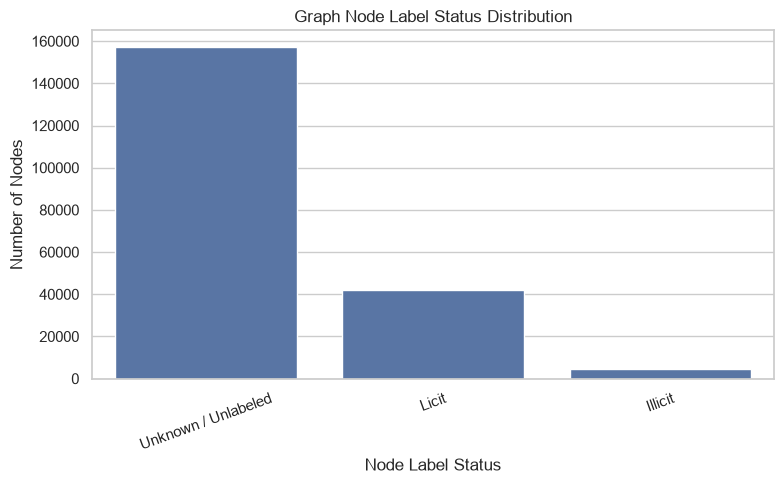

Unknown / Unlabeled    157205
Licit                   42019
Illicit                  4545
Name: count, dtype: int64

In [12]:
label_status_counts = pd.Series(labels).map({
    -1: "Unknown / Unlabeled",
     0: "Licit",
     1: "Illicit"
}).value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=label_status_counts.index, y=label_status_counts.values)
plt.title("Graph Node Label Status Distribution")
plt.xlabel("Node Label Status")
plt.ylabel("Number of Nodes")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "graph_node_label_status_distribution.png", dpi=300)
plt.show()

label_status_counts

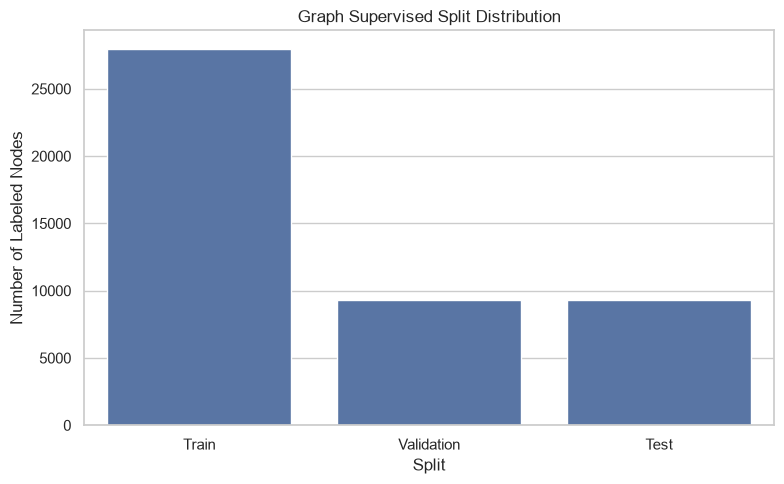

,split,count
0,Train,27938
1,Validation,9313
2,Test,9313


In [13]:
split_counts_df = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "count": [train_mask.sum(), val_mask.sum(), test_mask.sum()]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=split_counts_df, x="split", y="count")
plt.title("Graph Supervised Split Distribution")
plt.xlabel("Split")
plt.ylabel("Number of Labeled Nodes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "graph_supervised_split_distribution.png", dpi=300)
plt.show()

split_counts_df

## 6.11 Save Graph Data for GCN and GAT

The prepared graph data is saved as a compressed NumPy file. This file contains the scaled node features, labels, edge indices, train-validation-test masks, transaction IDs, and time-step information.

In [14]:
graph_file_path = GRAPH_DIR / "elliptic_graph_data.npz"
node_mapping_path = GRAPH_DIR / "node_mapping.csv"
scaler_path = GRAPH_DIR / "graph_feature_scaler.joblib"

np.savez_compressed(
    graph_file_path,
    x=X_all_scaled,
    y=labels,
    edge_index_directed=edge_index_directed,
    edge_index_undirected=edge_index_undirected,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
    tx_ids=features_df["txId"].values,
    time_step=features_df["time_step"].values
)

node_mapping_df.to_csv(node_mapping_path, index=False)
joblib.dump(scaler, scaler_path)

print("Graph data saved successfully.")
print("Saved graph file:", graph_file_path.relative_to(PROJECT_DIR))
print("Saved node mapping:", node_mapping_path.relative_to(PROJECT_DIR))
print("Saved scaler:", scaler_path.relative_to(PROJECT_DIR))

Graph data saved successfully.
Saved graph file: data\processed\graph_data\elliptic_graph_data.npz
Saved node mapping: data\processed\graph_data\node_mapping.csv
Saved scaler: data\processed\graph_data\graph_feature_scaler.joblib


In [15]:
loaded_graph = np.load(GRAPH_DIR / "elliptic_graph_data.npz")

print("Files inside saved graph object:")
print(loaded_graph.files)

print("\nLoaded x shape:", loaded_graph["x"].shape)
print("Loaded y shape:", loaded_graph["y"].shape)
print("Loaded directed edge index shape:", loaded_graph["edge_index_directed"].shape)
print("Loaded undirected edge index shape:", loaded_graph["edge_index_undirected"].shape)
print("Loaded train mask sum:", loaded_graph["train_mask"].sum())
print("Loaded validation mask sum:", loaded_graph["val_mask"].sum())
print("Loaded test mask sum:", loaded_graph["test_mask"].sum())

Files inside saved graph object:
['x', 'y', 'edge_index_directed', 'edge_index_undirected', 'train_mask', 'val_mask', 'test_mask', 'tx_ids', 'time_step']

Loaded x shape: (203769, 165)
Loaded y shape: (203769,)
Loaded directed edge index shape: (2, 234355)
Loaded undirected edge index shape: (2, 468710)
Loaded train mask sum: 27938
Loaded validation mask sum: 9313
Loaded test mask sum: 9313


## 6.12 Graph Data Preparation Summary

The Elliptic transaction graph has been prepared for graph neural network modeling. The final saved graph object contains the scaled node feature matrix, full label vector, directed and undirected edge indices, and supervised train-validation-test masks. Unlabeled transactions are retained in the graph because they may contribute useful neighborhood information during message passing, while only labeled nodes are used for supervised evaluation.

This prepared graph object will be used to train and evaluate GCN and GAT models.